# Illustration TRI brut vs TRI net

Ce notebook montre la différence entre TRI brut et TRI net, ainsi que leur évolution dans le temps, sur trois cas de figure:

1. Un seul versement initial
2. Seulement des versements programmés
3. Une combinaison des deux

Toutes les entrées sont paramétrables: montants, frais, rendement, durée.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

## Hypothèses de calcul

- TRI net: TRI calculé avec les flux réellement payés par le client (versements bruts incluant les frais d'entrée).
- TRI brut: TRI calculé avec les flux investis sur le contrat (versements nets après frais d'entrée).
- Même valorisation finale pour les deux TRI.

Par construction, le TRI brut est généralement supérieur au TRI net si des frais d'entrée existent.

In [2]:
def xirr(cashflows, dates, low=-0.9999, high=5.0, tol=1e-7, max_iter=200):
    """
    Calcule un TRI annualisé pour flux irréguliers via dichotomie.
    Retourne np.nan si le TRI n'est pas identifiable (pas de changement de signe).
    """
    cf = np.asarray(cashflows, dtype=float)
    if len(cf) == 0:
        return np.nan

    if np.all(cf >= 0) or np.all(cf <= 0):
        return np.nan

    d0 = pd.to_datetime(dates[0])
    t = np.array([(pd.to_datetime(d) - d0).days / 365.25 for d in dates], dtype=float)

    def npv(r):
        return np.sum(cf / np.power(1.0 + r, t))

    f_low = npv(low)
    f_high = npv(high)

    expand_count = 0
    while f_low * f_high > 0 and expand_count < 12:
        high *= 2
        f_high = npv(high)
        expand_count += 1

    if f_low * f_high > 0:
        return np.nan

    a, b = low, high
    fa, fb = f_low, f_high

    for _ in range(max_iter):
        m = 0.5 * (a + b)
        fm = npv(m)

        if abs(fm) < tol:
            return m

        if fa * fm <= 0:
            b, fb = m, fm
        else:
            a, fa = m, fm

    return 0.5 * (a + b)

In [3]:
def simulate_contract(
    scenario_name,
    start_date='2020-01-01',
    months=120,
    annual_return=0.05,
    entry_fee_rate=0.03,
    initial_gross=0.0,
    monthly_gross=0.0,
    monthly_start=1,
    monthly_end=None
):
    if monthly_end is None:
        monthly_end = months

    dates = pd.date_range(pd.to_datetime(start_date), periods=months + 1, freq='ME')
    monthly_return = (1.0 + annual_return) ** (1.0 / 12.0) - 1.0

    portfolio_value = 0.0
    rows = []

    cashflows_gross_dates = []
    cashflows_gross_values = []
    cashflows_net_dates = []
    cashflows_net_values = []

    for i, dt in enumerate(dates):
        gross_contrib = 0.0

        if i == 0 and initial_gross > 0:
            gross_contrib += initial_gross

        if i >= monthly_start and i <= monthly_end and monthly_gross > 0:
            gross_contrib += monthly_gross

        fees = gross_contrib * entry_fee_rate
        net_contrib = gross_contrib - fees

        if gross_contrib > 0:
            cashflows_gross_dates.append(dt)
            cashflows_gross_values.append(-gross_contrib)
            cashflows_net_dates.append(dt)
            cashflows_net_values.append(-net_contrib)

        portfolio_value = (portfolio_value + net_contrib) * (1.0 + monthly_return)

        tri_net = np.nan
        tri_brut = np.nan

        if len(cashflows_gross_values) > 0 and portfolio_value > 0:
            tri_net = xirr(
                cashflows_gross_values + [portfolio_value],
                cashflows_gross_dates + [dt]
            )

        if len(cashflows_net_values) > 0 and portfolio_value > 0:
            tri_brut = xirr(
                cashflows_net_values + [portfolio_value],
                cashflows_net_dates + [dt]
            )

        rows.append({
            'Scenario': scenario_name,
            'Date': dt,
            'Versement brut': gross_contrib,
            'Frais entree': fees,
            'Versement net': net_contrib,
            'Valorisation': portfolio_value,
            'TRI net': tri_net,
            'TRI brut': tri_brut,
            'Ecart TRI (points)': (tri_brut - tri_net) * 100 if pd.notna(tri_brut) and pd.notna(tri_net) else np.nan
        })

    return pd.DataFrame(rows)

## Paramètres des scénarios

Modifiez librement les paramètres ci-dessous:

- annual_return: rendement annuel attendu
- entry_fee_rate: frais d'entrée
- initial_gross: versement initial brut
- monthly_gross: versement programmé brut
- monthly_start, monthly_end: fenêtre des versements programmés

In [4]:
common = dict(
    start_date='2020-01-01',
    months=180,
    annual_return=0.055,
    entry_fee_rate=0.03
)

scenarios = {
    '1) Versement initial unique': dict(
        **common,
        initial_gross=50000,
        monthly_gross=0,
        monthly_start=1,
        monthly_end=180
    ),
    '2) Versements programmes seuls': dict(
        **common,
        initial_gross=0,
        monthly_gross=500,
        monthly_start=1,
        monthly_end=180
    ),
    '3) Combinaison initial + programmes': dict(
        **common,
        initial_gross=20000,
        monthly_gross=350,
        monthly_start=1,
        monthly_end=180
    )
}

pd.DataFrame(scenarios).T

,start_date,months,annual_return,entry_fee_rate,initial_gross,monthly_gross,monthly_start,monthly_end
1) Versement initial unique,2020-01-01,180,0.055,0.03,50000,0,1,180
2) Versements programmes seuls,2020-01-01,180,0.055,0.03,0,500,1,180
3) Combinaison initial + programmes,2020-01-01,180,0.055,0.03,20000,350,1,180


In [5]:
all_df = []
for sc_name, params in scenarios.items():
    all_df.append(simulate_contract(sc_name, **params))

df_all = pd.concat(all_df, ignore_index=True)
df_all.head()

,Scenario,Date,Versement brut,Frais entree,Versement net,Valorisation,TRI net,TRI brut,Ecart TRI (points)
0,1) Versement initial unique,2020-01-31,50000.0,1500.0,48500.0,48716.877397,NaN,NaN,NaN
1,1) Versement initial unique,2020-02-29,0.0,0.0,0.0,48934.724605,-0.237566,0.118949,35.651431
2,1) Versement initial unique,2020-03-31,0.0,0.0,0.0,49153.545960,-0.098719,0.084894,18.361296
3,1) Versement initial unique,2020-04-30,0.0,0.0,0.0,49373.345819,-0.049897,0.075116,12.501319
4,1) Versement initial unique,2020-05-31,0.0,0.0,0.0,49594.128556,-0.024303,0.069660,9.396298


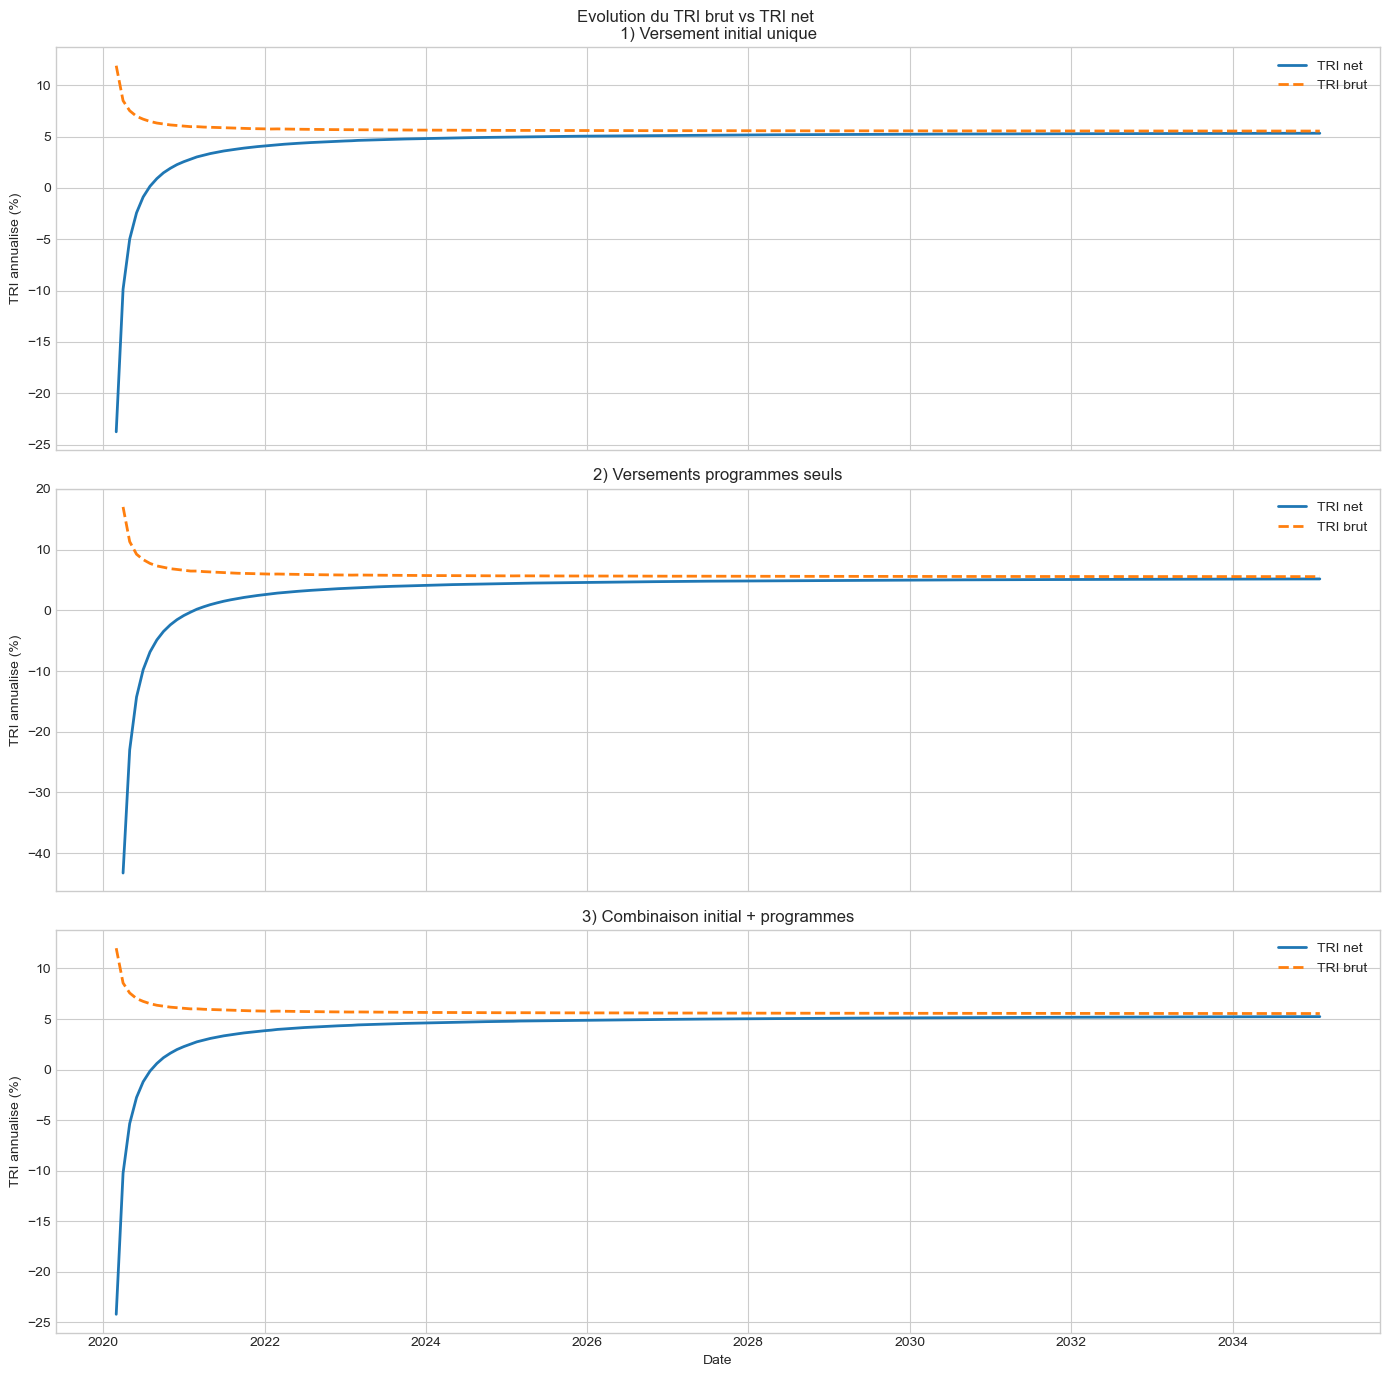

In [6]:
# Courbes TRI brut / TRI net dans le temps
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

for i, scenario in enumerate(df_all['Scenario'].unique()):
    d = df_all[df_all['Scenario'] == scenario].copy()
    axes[i].plot(d['Date'], d['TRI net'] * 100, label='TRI net', linewidth=2)
    axes[i].plot(d['Date'], d['TRI brut'] * 100, label='TRI brut', linewidth=2, linestyle='--')
    axes[i].set_title(scenario)
    axes[i].set_ylabel('TRI annualise (%)')
    axes[i].legend(loc='best')

axes[-1].set_xlabel('Date')
plt.suptitle('Evolution du TRI brut vs TRI net')
plt.tight_layout()
plt.show()

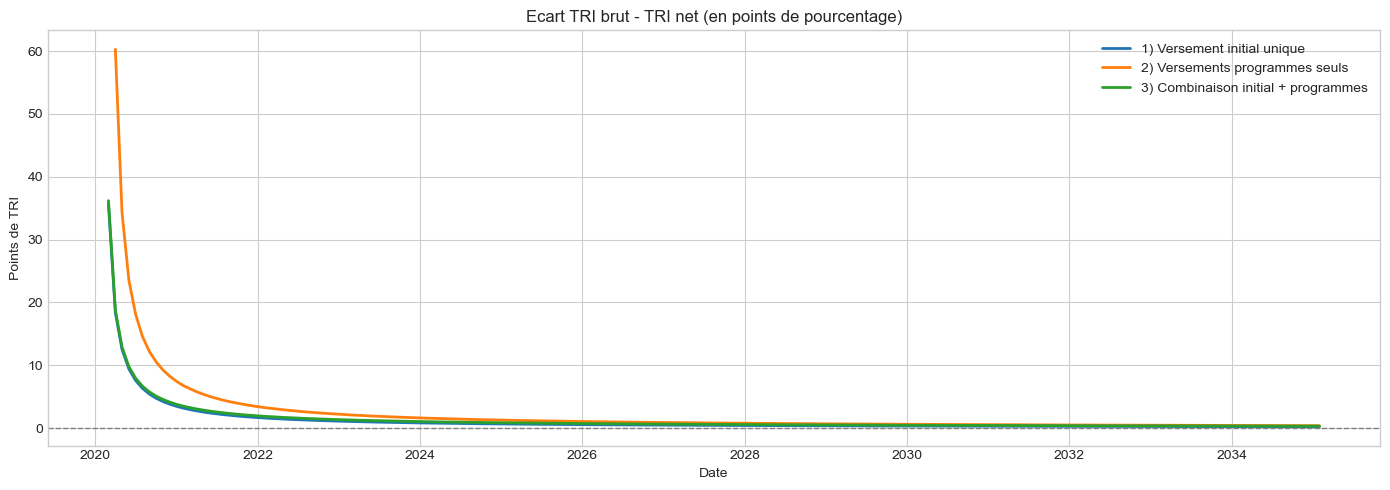

In [7]:
# Evolution de l'ecart relatif dans le temps
plt.figure(figsize=(14, 5))
for scenario in df_all['Scenario'].unique():
    d = df_all[df_all['Scenario'] == scenario].copy()
    plt.plot(d['Date'], d['Ecart TRI (points)'], label=scenario, linewidth=2)

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Ecart TRI brut - TRI net (en points de pourcentage)')
plt.xlabel('Date')
plt.ylabel('Points de TRI')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [8]:
# Tableau de synthese final
summary_rows = []

for scenario in df_all['Scenario'].unique():
    d = df_all[df_all['Scenario'] == scenario].copy()
    last = d.dropna(subset=['TRI net', 'TRI brut']).iloc[-1]

    total_gross = d['Versement brut'].sum()
    total_net = d['Versement net'].sum()
    total_fees = d['Frais entree'].sum()

    summary_rows.append({
        'Scenario': scenario,
        'Versements bruts': round(total_gross, 2),
        'Versements nets': round(total_net, 2),
        'Frais entree': round(total_fees, 2),
        'Valorisation finale': round(last['Valorisation'], 2),
        'TRI net final (%)': round(last['TRI net'] * 100, 2),
        'TRI brut final (%)': round(last['TRI brut'] * 100, 2),
        'Ecart final (points)': round((last['TRI brut'] - last['TRI net']) * 100, 2)
    })

df_summary = pd.DataFrame(summary_rows).sort_values('Scenario')
df_summary

,Scenario,Versements bruts,Versements nets,Frais entree,Valorisation finale,TRI net final (%),TRI brut final (%),Ecart final (points)
0,1) Versement initial unique,50000.0,48500.0,1500.0,108759.28,5.32,5.53,0.21
1,2) Versements programmes seuls,90000.0,87300.0,2700.0,134272.02,5.17,5.55,0.38
2,3) Combinaison initial + programmes,83000.0,80510.0,2490.0,137494.13,5.24,5.54,0.31


## Lecture rapide

- Les frais d'entrée creusent l'écart entre TRI brut et TRI net.
- Cet écart est d'autant plus visible que les frais sont élevés et que les flux sont fréquents.
- En modifiant annual_return, entry_fee_rate, initial_gross et monthly_gross, vous pouvez tester vos propres hypothèses.